
# EXPLORATORY DATA ANALYSIS

In [36]:
# =========================================================
# CELL 1: LOAD DATA + CLEANING + PANEL STRUCTURE
# (Integrated version of Section 4.3)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_excel(
    r"C:\Users\Joel\OneDrive - Nanyang Technological University\FYP Research\EXPERIMENTDATA\Final FYP Dataset .xlsx"
)

# Standardize column names
df.columns = df.columns.str.lower().str.strip()

# ------------------------------
# Basic cleaning
# ------------------------------
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df["id_in_group"] = pd.to_numeric(df["id_in_group"], errors="coerce")
df["participant_id"] = pd.to_numeric(df["participant_id"], errors="coerce")

df["network_type"] = df["network_type"].astype(str).str.lower().str.strip()
df["signal"] = df["signal"].astype(str).str.upper().str.strip()
df["state"] = df["state"].astype(str).str.upper().str.strip()
df["role"] = df["role"].astype(str).str.lower().str.strip()
df["participant_code"] = df["participant_code"].astype(str).str.strip()

# ------------------------------
# TRUE unique player ID
# ------------------------------
df["player_id"] = df["participant_code"]

# ------------------------------
# Reconstruct experimental blocks
# ------------------------------
player_order = (
    df[["player_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

player_order["player_seq"] = np.arange(1, len(player_order) + 1)

# Each block contains 8 players
player_order["block_id"] = ((player_order["player_seq"] - 1) // 8) + 1

# Merge block info back
df = df.merge(player_order, on="player_id", how="left")

# ------------------------------
# Session ID
# ------------------------------
df["session_id"] = np.where(df["block_id"].isin([1,2,3,4]), 1, 2)

# ------------------------------
# Group ID
# ------------------------------
df["group_id"] = df["block_id"]

# ------------------------------
# Group within treatment
# ------------------------------
ring_map = {1:1, 2:2, 5:3}
hub_map  = {3:1, 4:2, 6:3}

df["group_in_treatment"] = np.nan

df.loc[df["network_type"]=="ring","group_in_treatment"] = (
    df.loc[df["network_type"]=="ring","block_id"].map(ring_map)
)

df.loc[df["network_type"]=="hub","group_in_treatment"] = (
    df.loc[df["network_type"]=="hub","block_id"].map(hub_map)
)

df["group_in_treatment"] = df["group_in_treatment"].astype(int)

# ------------------------------
# Key variables
# ------------------------------
df["belief_prob"] = df["belief"] / 100

df["hub_network"] = (df["network_type"]=="hub").astype(int)
df["signal_high"] = (df["signal"]=="HIGH").astype(int)
df["state_high"]  = (df["state"]=="HIGH").astype(int)
df["is_hub"]      = (df["role"]=="hub").astype(int)

df["belief_error"] = np.abs(df["belief_prob"] - df["state_high"])
df["belief_accuracy"] = 1 - df["belief_error"]

# ------------------------------
# Panel sorting
# ------------------------------
df = df.sort_values(
    ["session_id","group_id","player_id","round"]
).reset_index(drop=True)

# ------------------------------
# Lag variables for learning
# ------------------------------
df["lag_belief"] = df.groupby("player_id")["belief_prob"].shift(1)
df["delta_belief"] = df.groupby("player_id")["belief_prob"].diff()

# ------------------------------
# Verification
# ------------------------------
print("Dataset shape:", df.shape)
print("Unique players:", df["player_id"].nunique())
print("Unique groups:", df["group_id"].nunique())
print("Unique sessions:", df["session_id"].nunique())
print("Rounds:", df["round"].nunique())

print("\nPlayers per group:")
print(df[["group_id","player_id"]].drop_duplicates().groupby("group_id").size())

print("\nUnique players by network:")
print(df[["network_type","player_id"]].drop_duplicates().groupby("network_type").size())

print("\nObservations per player:")
print(df.groupby("player_id").size().value_counts().sort_index())

# ------------------------------
# Visualization settings
# ------------------------------
network_palette = {
    "hub": "#1f77b4",
    "ring": "#ff7f0e"
}

network_order = ["hub","ring"]

sns.set_style("whitegrid")

Dataset shape: (720, 29)
Unique players: 48
Unique groups: 6
Unique sessions: 2
Rounds: 15

Players per group:
group_id
1    8
2    8
3    8
4    8
5    8
6    8
dtype: int64

Unique players by network:
network_type
hub     24
ring    24
dtype: int64

Observations per player:
15    48
Name: count, dtype: int64



OVERALL DESCRIPTIVE STATISTICS
       contribution      belief  belief_prob  belief_accuracy
count    720.000000  720.000000   720.000000       720.000000
mean       8.701389   53.350000     0.533500         0.572139
std        6.429764   31.066437     0.310664         0.304015
min        0.000000    0.000000     0.000000         0.000000
25%        4.000000   32.000000     0.320000         0.380000
50%        8.000000   50.000000     0.500000         0.500000
75%       12.000000   80.000000     0.800000         0.840000
max       20.000000  100.000000     1.000000         1.000000

MEAN OUTCOMES BY NETWORK
              contribution  belief_prob  belief_accuracy
network_type                                            
hub                  9.139        0.494            0.560
ring                 8.264        0.573            0.584

Mean contribution by network (all states)
network_type
hub     9.139
ring    8.264
Name: contribution, dtype: float64

Mean contribution by network (HIGH s

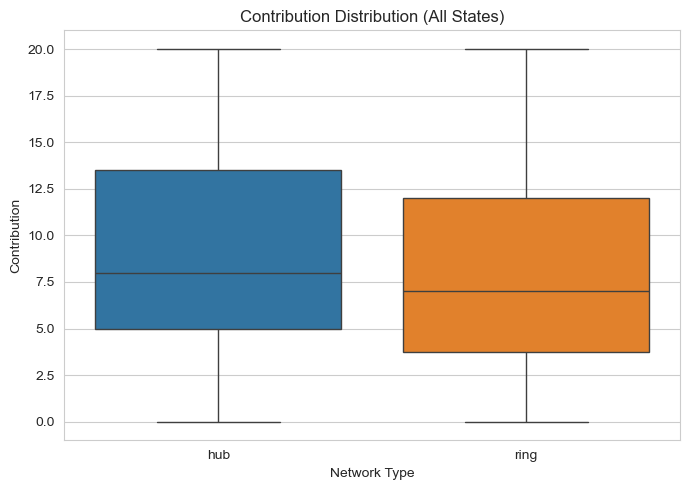

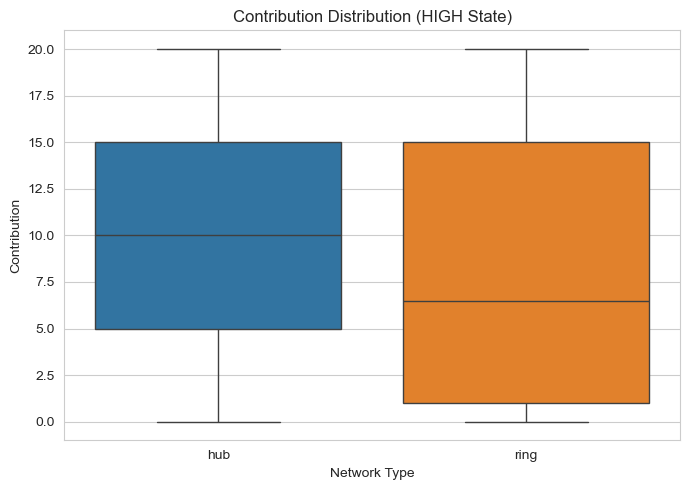

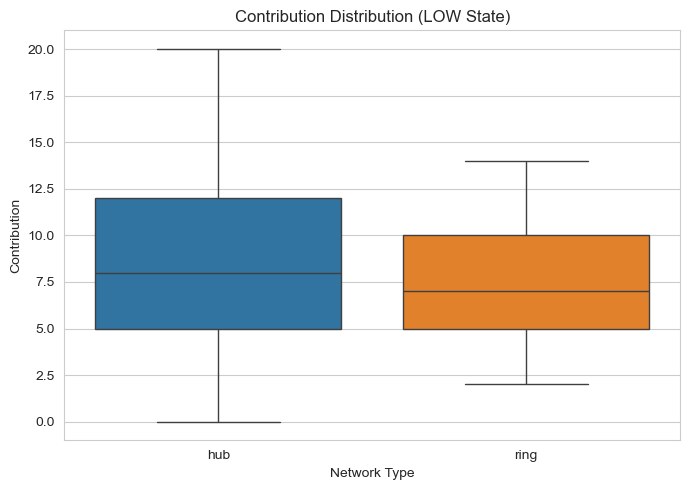


CONTRIBUTION VS BELIEF GRADIENTS
All States | Hub gradient (slope): 9.3300
All States | Ring gradient (slope): 9.7070


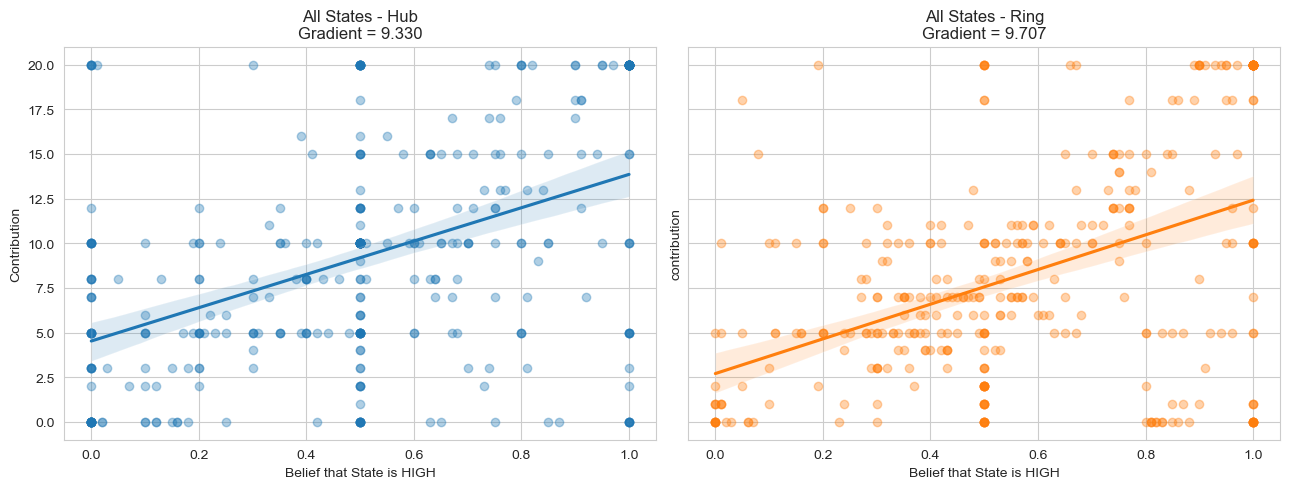

HIGH State | Hub gradient (slope): 9.2830
HIGH State | Ring gradient (slope): 9.5665


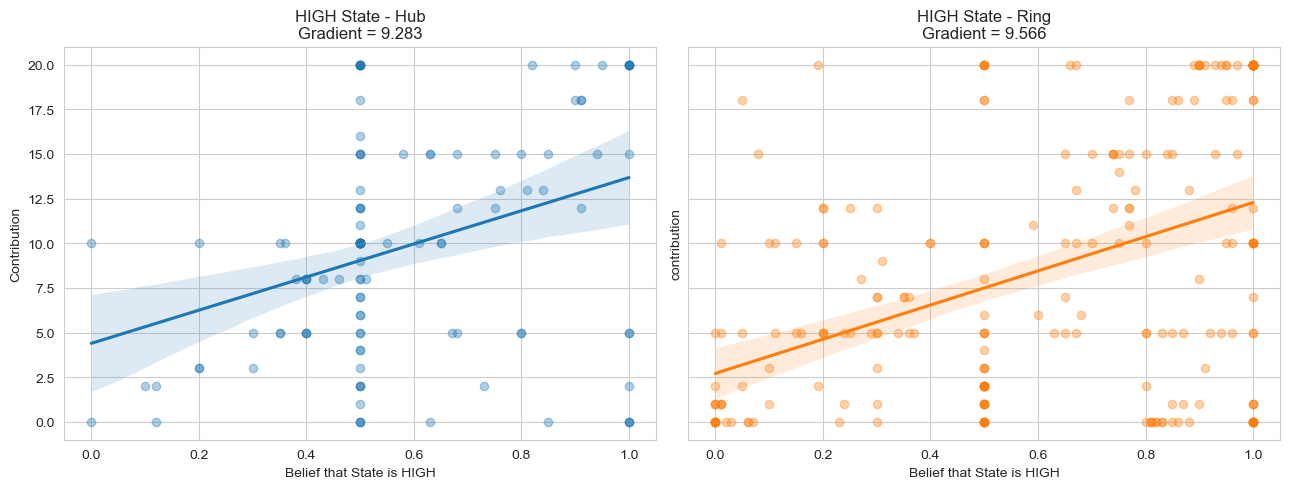

LOW State | Hub gradient (slope): 9.4249
LOW State | Ring gradient (slope): 12.3758


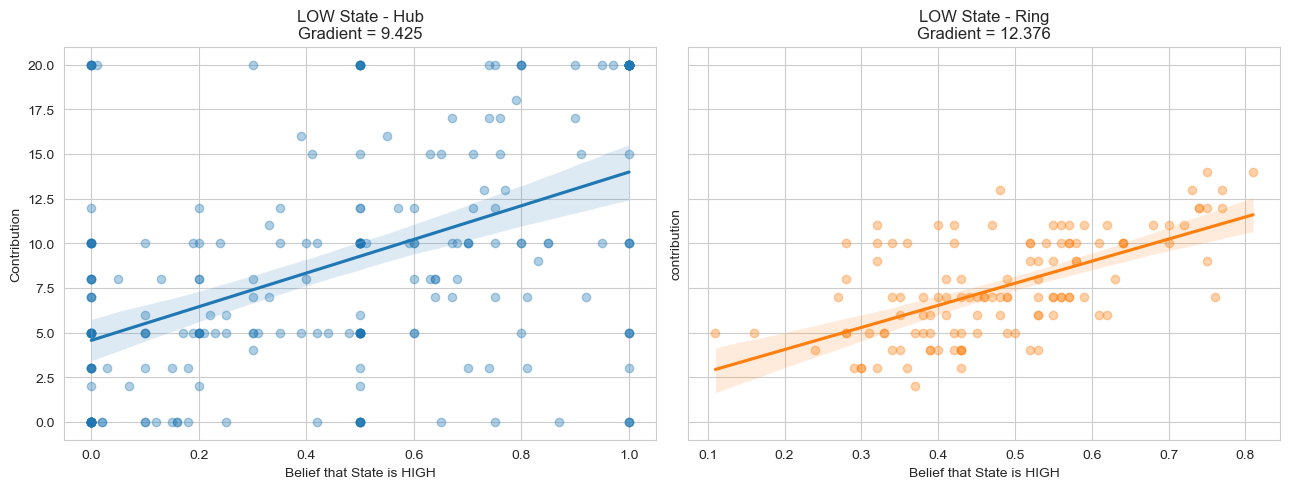

In [40]:
# =========================================================
# CELL 2: DESCRIPTIVE STATISTICS + DISTRIBUTIONS + SLOPES
# Uses cleaned df from Cell 1
# =========================================================

print("\n==============================")
print("OVERALL DESCRIPTIVE STATISTICS")
print("==============================")
print(df[["contribution", "belief", "belief_prob", "belief_accuracy"]].describe())

print("\n==============================")
print("MEAN OUTCOMES BY NETWORK")
print("==============================")
print(
    df.groupby("network_type")[["contribution", "belief_prob", "belief_accuracy"]]
    .mean()
    .round(3)
)

print("\nMean contribution by network (all states)")
print(df.groupby("network_type")["contribution"].mean().round(3))

print("\nMean contribution by network (HIGH state only)")
print(
    df[df["state"] == "HIGH"]
    .groupby("network_type")["contribution"]
    .mean()
    .round(3)
)

print("\nMean contribution by network (LOW state only)")
print(
    df[df["state"] == "LOW"]
    .groupby("network_type")["contribution"]
    .mean()
    .round(3)
)

print("\nMean belief accuracy by network (all states)")
print(df.groupby("network_type")["belief_accuracy"].mean().round(3))

print("\nMean belief accuracy by network (HIGH state only)")
print(
    df[df["state"] == "HIGH"]
    .groupby("network_type")["belief_accuracy"]
    .mean()
    .round(3)
)

print("\nMean belief accuracy by network (LOW state only)")
print(
    df[df["state"] == "LOW"]
    .groupby("network_type")["belief_accuracy"]
    .mean()
    .round(3)
)

print("\n==============================")
print("COUNTS CHECK")
print("==============================")
print("Observations by network:")
print(df.groupby("network_type").size())

print("\nObservations by state:")
print(df.groupby("state").size())

print("\nObservations by network and state:")
print(df.groupby(["network_type", "state"]).size())

# ------------------------------
# Contribution distributions
# ------------------------------

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df,
    x="network_type",
    y="contribution",
    order=network_order,
    hue="network_type",
    palette=network_palette,
    dodge=False
)
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Contribution Distribution (All States)")
plt.xlabel("Network Type")
plt.ylabel("Contribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df[df["state"] == "HIGH"],
    x="network_type",
    y="contribution",
    order=network_order,
    hue="network_type",
    palette=network_palette,
    dodge=False
)
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Contribution Distribution (HIGH State)")
plt.xlabel("Network Type")
plt.ylabel("Contribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df[df["state"] == "LOW"],
    x="network_type",
    y="contribution",
    order=network_order,
    hue="network_type",
    palette=network_palette,
    dodge=False
)
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Contribution Distribution (LOW State)")
plt.xlabel("Network Type")
plt.ylabel("Contribution")
plt.tight_layout()
plt.show()

# ------------------------------
# Helper function: slope + plot
# ------------------------------
def plot_belief_contribution_with_slope(data, title_prefix):
    """
    Creates 2 side-by-side regplots for hub and ring
    and prints the gradient (slope) from a simple OLS:
    contribution ~ belief_prob
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    for i, net in enumerate(network_order):
        sub = data[data["network_type"] == net].copy()

        if len(sub) < 2 or sub["belief_prob"].nunique() < 2:
            axes[i].text(0.5, 0.5, f"Not enough variation for {net}", ha="center", va="center")
            axes[i].set_title(f"{title_prefix} - {net.capitalize()}")
            axes[i].set_xlabel("Belief that State is HIGH")
            if i == 0:
                axes[i].set_ylabel("Contribution")
            continue

        reg = smf.ols("contribution ~ belief_prob", data=sub).fit()
        slope = reg.params["belief_prob"]

        sns.regplot(
            data=sub,
            x="belief_prob",
            y="contribution",
            ax=axes[i],
            scatter_kws={"alpha": 0.35},
            color=network_palette[net]
        )

        axes[i].set_title(f"{title_prefix} - {net.capitalize()}\nGradient = {slope:.3f}")
        axes[i].set_xlabel("Belief that State is HIGH")
        if i == 0:
            axes[i].set_ylabel("Contribution")

        print(f"{title_prefix} | {net.capitalize()} gradient (slope): {slope:.4f}")

    plt.tight_layout()
    plt.show()

# ------------------------------
# Contribution vs Belief:
# split by state and network
# ------------------------------
print("\n==============================")
print("CONTRIBUTION VS BELIEF GRADIENTS")
print("==============================")

plot_belief_contribution_with_slope(df, "All States")
plot_belief_contribution_with_slope(
    df[df["state"] == "HIGH"],
    "HIGH State"
)
plot_belief_contribution_with_slope(
    df[df["state"] == "LOW"],
    "LOW State"
)

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


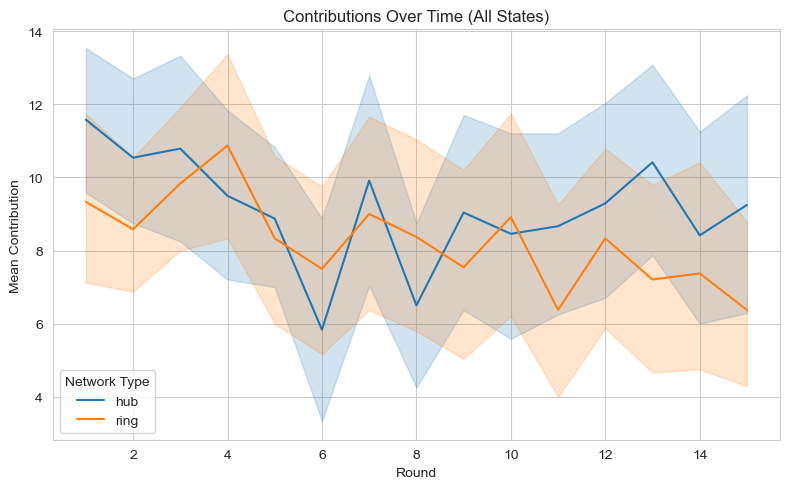

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


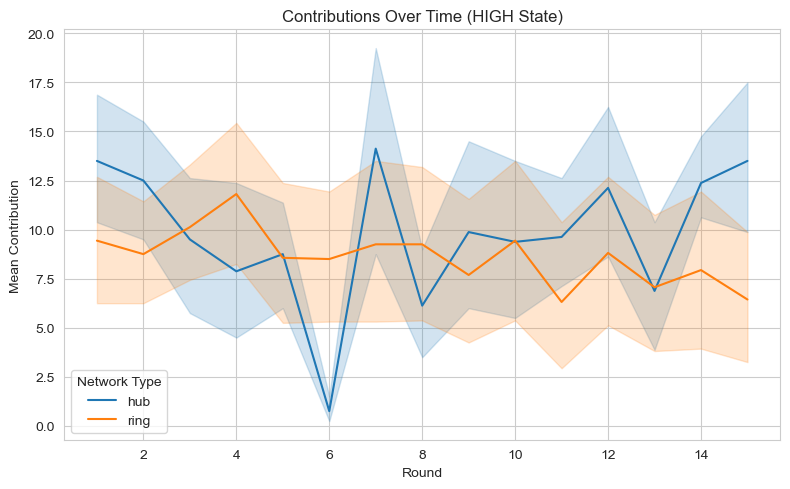

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


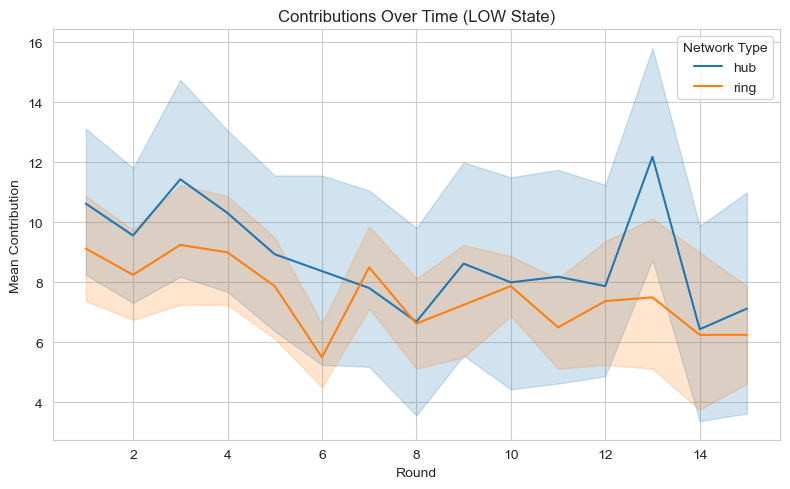

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


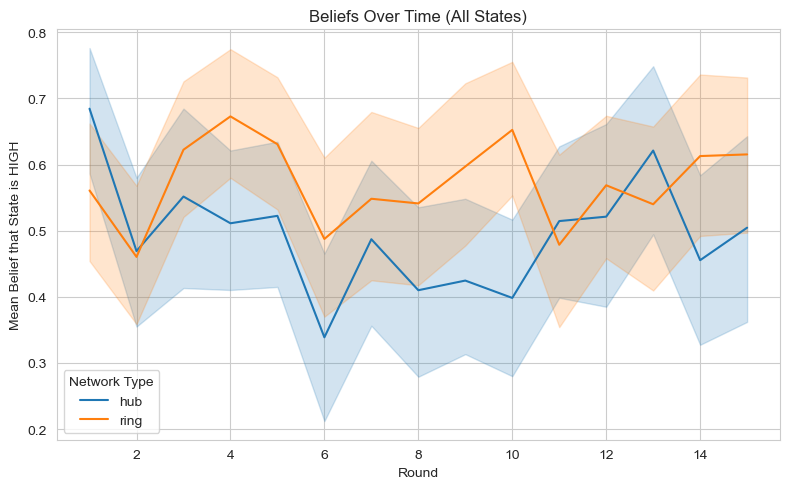

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:80: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


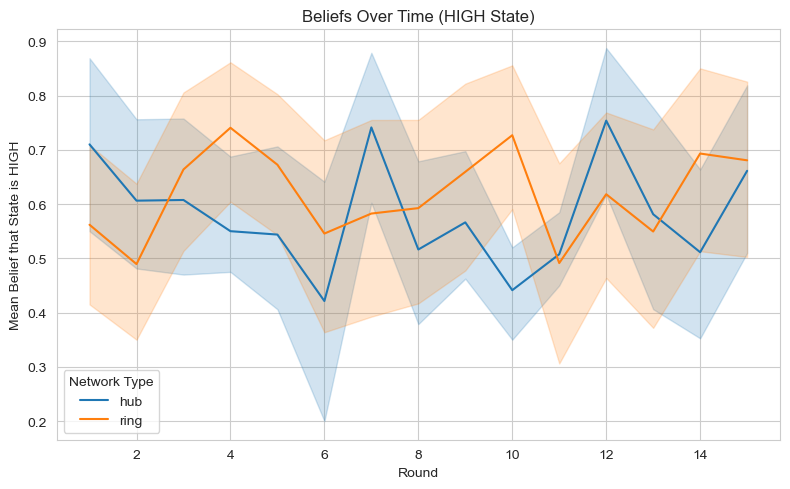

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:97: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


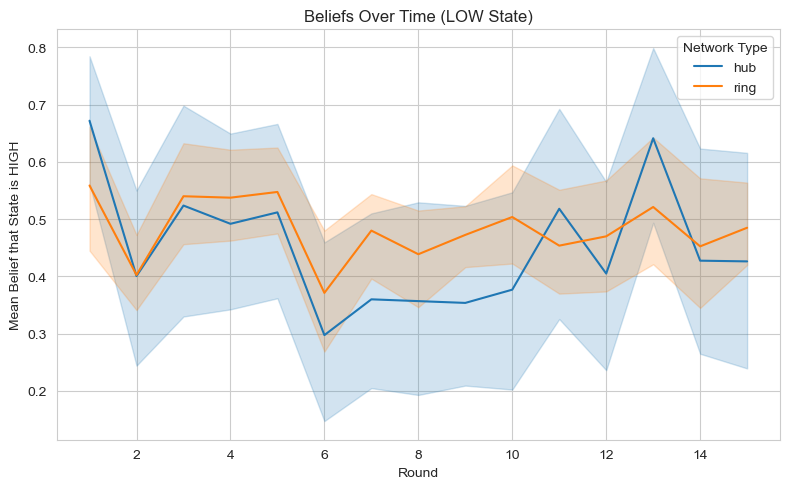

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:117: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


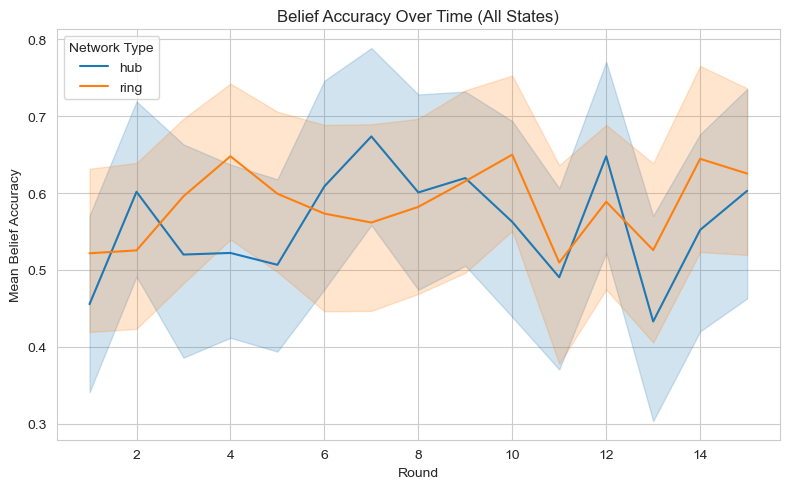

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:134: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


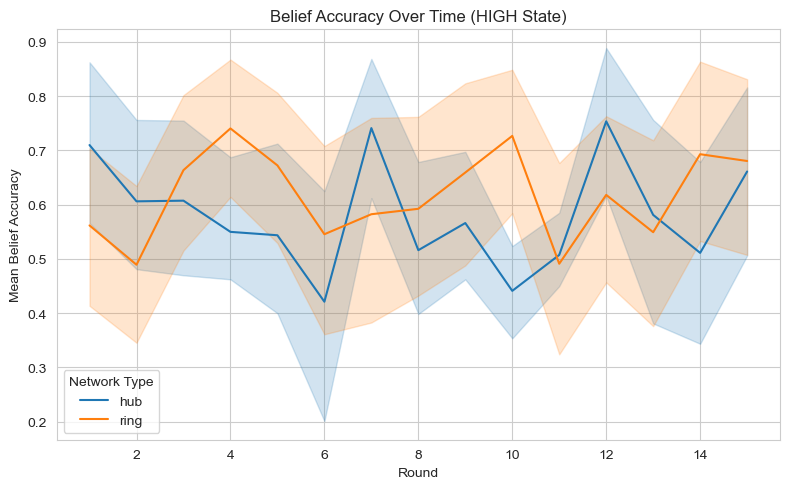

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\3405208297.py:151: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


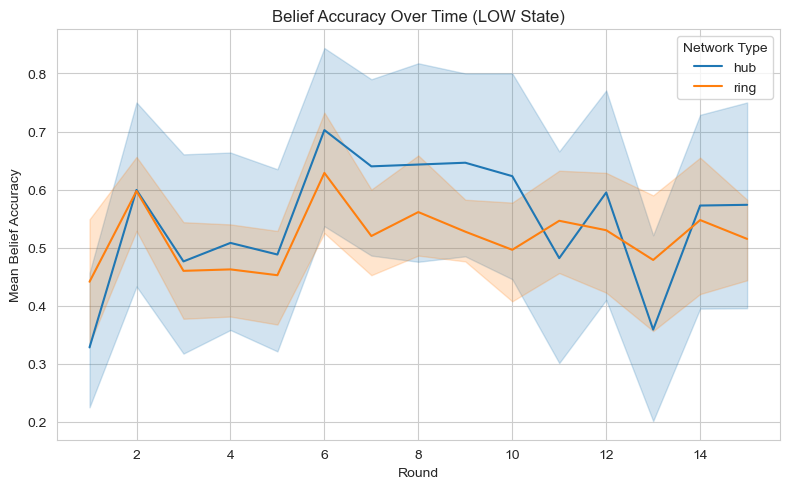

In [41]:
# =========================================================
# CELL 3: NETWORK DYNAMICS OVER TIME
# =========================================================

# ------------------------------
# Contributions over time
# ------------------------------
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="round",
    y="contribution",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Contributions Over Time (All States)")
plt.xlabel("Round")
plt.ylabel("Mean Contribution")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "HIGH"],
    x="round",
    y="contribution",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Contributions Over Time (HIGH State)")
plt.xlabel("Round")
plt.ylabel("Mean Contribution")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "LOW"],
    x="round",
    y="contribution",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Contributions Over Time (LOW State)")
plt.xlabel("Round")
plt.ylabel("Mean Contribution")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

# ------------------------------
# Beliefs over time
# ------------------------------
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="round",
    y="belief_prob",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Beliefs Over Time (All States)")
plt.xlabel("Round")
plt.ylabel("Mean Belief that State is HIGH")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "HIGH"],
    x="round",
    y="belief_prob",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Beliefs Over Time (HIGH State)")
plt.xlabel("Round")
plt.ylabel("Mean Belief that State is HIGH")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "LOW"],
    x="round",
    y="belief_prob",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Beliefs Over Time (LOW State)")
plt.xlabel("Round")
plt.ylabel("Mean Belief that State is HIGH")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

# ------------------------------
# Belief accuracy over time
# ------------------------------
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="round",
    y="belief_accuracy",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Belief Accuracy Over Time (All States)")
plt.xlabel("Round")
plt.ylabel("Mean Belief Accuracy")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "HIGH"],
    x="round",
    y="belief_accuracy",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Belief Accuracy Over Time (HIGH State)")
plt.xlabel("Round")
plt.ylabel("Mean Belief Accuracy")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "LOW"],
    x="round",
    y="belief_accuracy",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Belief Accuracy Over Time (LOW State)")
plt.xlabel("Round")
plt.ylabel("Mean Belief Accuracy")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

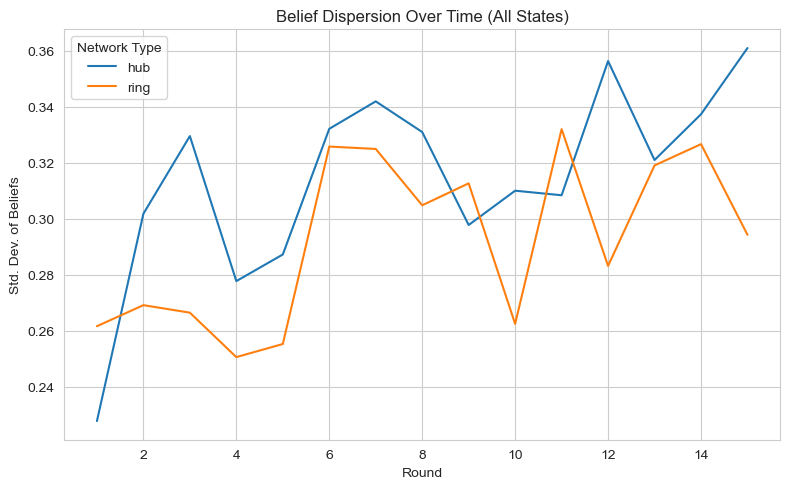

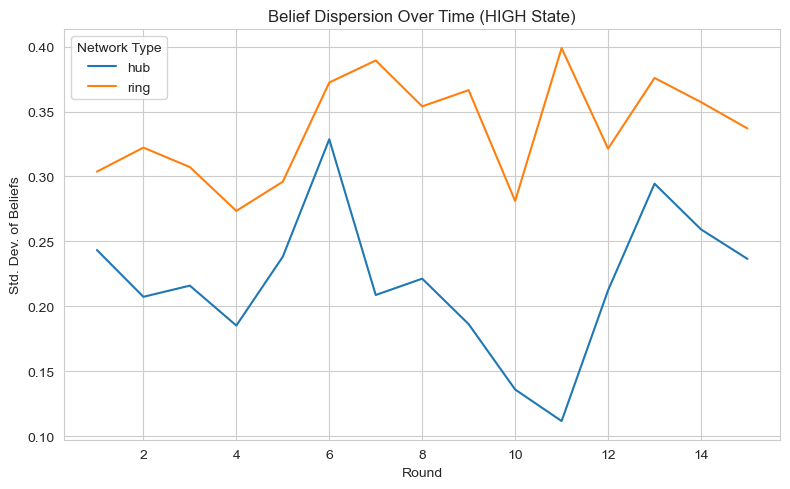

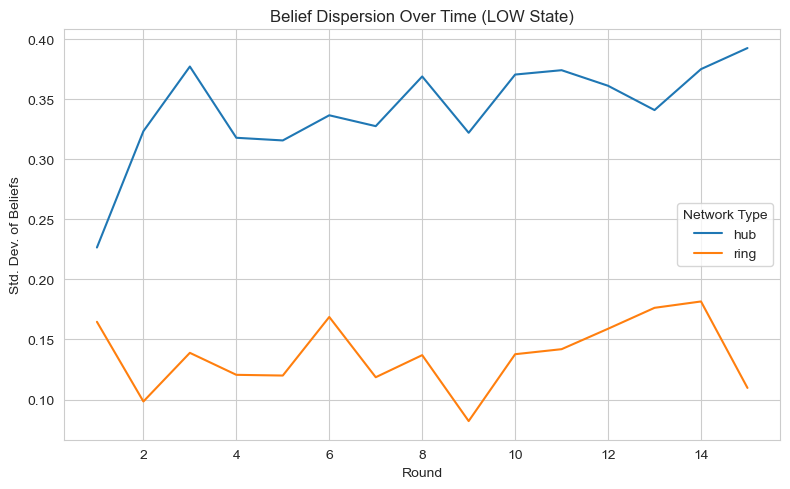

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\1492372928.py:82: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


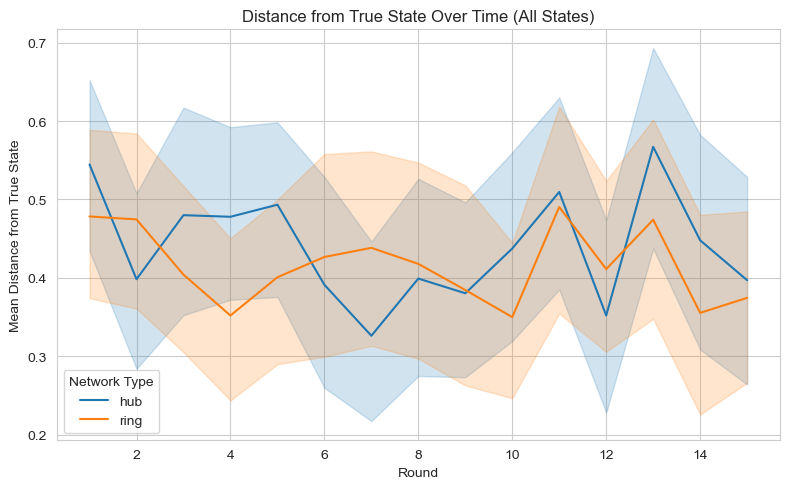

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\1492372928.py:99: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


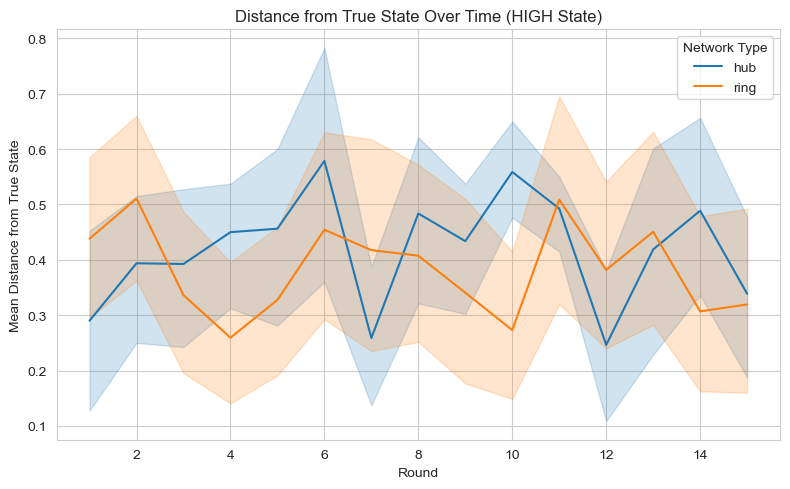

C:\Users\Joel\AppData\Local\Temp\ipykernel_28420\1492372928.py:116: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


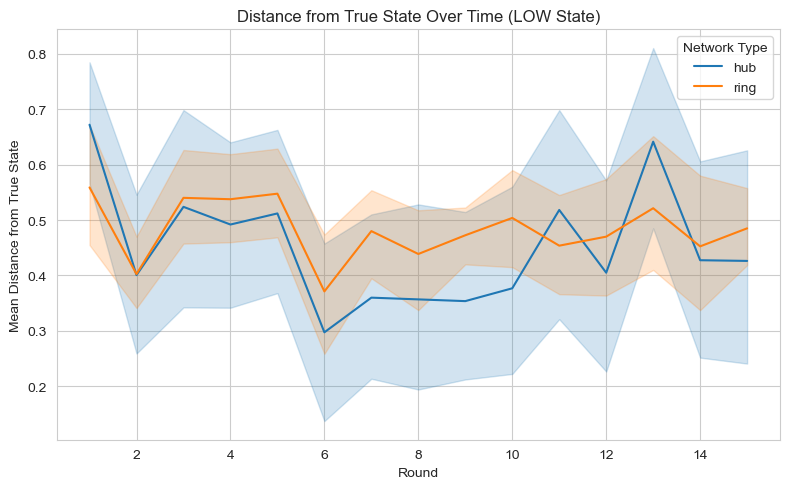

Observed signal accuracy: 0.5861


In [42]:
# =========================================================
# CELL 4: INFORMATION AGGREGATION AND LEARNING DIAGNOSTICS
# =========================================================

# ------------------------------
# Belief dispersion over time
# ------------------------------
belief_var_all = (
    df.groupby(["network_type", "round"])["belief_prob"]
      .std()
      .reset_index(name="belief_sd")
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=belief_var_all,
    x="round",
    y="belief_sd",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette
)
plt.title("Belief Dispersion Over Time (All States)")
plt.xlabel("Round")
plt.ylabel("Std. Dev. of Beliefs")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

belief_var_high = (
    df[df["state"].astype(str).str.upper() == "HIGH"]
    .groupby(["network_type", "round"])["belief_prob"]
    .std()
    .reset_index(name="belief_sd")
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=belief_var_high,
    x="round",
    y="belief_sd",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette
)
plt.title("Belief Dispersion Over Time (HIGH State)")
plt.xlabel("Round")
plt.ylabel("Std. Dev. of Beliefs")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

belief_var_low = (
    df[df["state"].astype(str).str.upper() == "LOW"]
    .groupby(["network_type", "round"])["belief_prob"]
    .std()
    .reset_index(name="belief_sd")
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=belief_var_low,
    x="round",
    y="belief_sd",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette
)
plt.title("Belief Dispersion Over Time (LOW State)")
plt.xlabel("Round")
plt.ylabel("Std. Dev. of Beliefs")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

# ------------------------------
# Distance from true state
# ------------------------------
df["belief_distance_from_truth"] = np.abs(df["belief_prob"] - df["state_high"])

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="round",
    y="belief_distance_from_truth",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Distance from True State Over Time (All States)")
plt.xlabel("Round")
plt.ylabel("Mean Distance from True State")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "HIGH"],
    x="round",
    y="belief_distance_from_truth",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Distance from True State Over Time (HIGH State)")
plt.xlabel("Round")
plt.ylabel("Mean Distance from True State")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df[df["state"].astype(str).str.upper() == "LOW"],
    x="round",
    y="belief_distance_from_truth",
    hue="network_type",
    hue_order=network_order,
    palette=network_palette,
    ci=95
)
plt.title("Distance from True State Over Time (LOW State)")
plt.xlabel("Round")
plt.ylabel("Mean Distance from True State")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()

# ------------------------------
# Observed signal accuracy
# ------------------------------
observed_signal_accuracy = (df["signal_high"] == df["state_high"]).mean()
print("Observed signal accuracy:", round(observed_signal_accuracy, 4))


# Regression and Modelling


## Data Cleaning according to 3 Unique groups for each Network Type (Ring/Hub-Spoke)

In [30]:
# =========================================================
# SECTION 4.3 SETUP: LOAD + CLEAN + RECONSTRUCT TRUE IDs
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_excel(r"C:\Users\Joel\OneDrive - Nanyang Technological University\FYP Research\EXPERIMENTDATA\Final FYP Dataset .xlsx")
df.columns = df.columns.str.lower().str.strip()

# ------------------------------
# Basic cleaning
# ------------------------------
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df["id_in_group"] = pd.to_numeric(df["id_in_group"], errors="coerce")
df["participant_id"] = pd.to_numeric(df["participant_id"], errors="coerce")

df["network_type"] = df["network_type"].astype(str).str.lower().str.strip()
df["signal"] = df["signal"].astype(str).str.upper().str.strip()
df["state"] = df["state"].astype(str).str.upper().str.strip()
df["role"] = df["role"].astype(str).str.lower().str.strip()
df["participant_code"] = df["participant_code"].astype(str).str.strip()

# ------------------------------
# TRUE unique player ID
# ------------------------------
# participant_code is the real unique identifier
df["player_id"] = df["participant_code"]

# ------------------------------
# Reconstruct experimental blocks from first appearance
# Each unique player appears in one contiguous 15-row block.
# The 48 players appear in 6 blocks of 8 players:
#   1 = ring group 1
#   2 = ring group 2
#   3 = hub group 1
#   4 = hub group 2
#   5 = ring group 3
#   6 = hub group 3
# ------------------------------
player_order = (
    df[["player_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
player_order["player_seq"] = np.arange(1, len(player_order) + 1)

# block_id = 1..6, each block has 8 players
player_order["block_id"] = ((player_order["player_seq"] - 1) // 8) + 1

# Merge back
df = df.merge(player_order, on="player_id", how="left")

# ------------------------------
# Session ID
# Session 1 = first 4 blocks
# Session 2 = last 2 blocks
# ------------------------------
df["session_id"] = np.where(df["block_id"].isin([1, 2, 3, 4]), 1, 2)

# ------------------------------
# Group ID within the full experiment
# We want 6 unique groups total
# ------------------------------
df["group_id"] = df["block_id"]

# ------------------------------
# Group number within treatment
# Ring groups = 1,2,3 ; Hub groups = 1,2,3
# ------------------------------
ring_map = {1: 1, 2: 2, 5: 3}
hub_map = {3: 1, 4: 2, 6: 3}

df["group_in_treatment"] = np.nan
df.loc[df["network_type"] == "ring", "group_in_treatment"] = df.loc[df["network_type"] == "ring", "block_id"].map(ring_map)
df.loc[df["network_type"] == "hub", "group_in_treatment"] = df.loc[df["network_type"] == "hub", "block_id"].map(hub_map)
df["group_in_treatment"] = df["group_in_treatment"].astype(int)

# ------------------------------
# Key variables
# ------------------------------
df["belief_prob"] = df["belief"] / 100
df["hub_network"] = (df["network_type"] == "hub").astype(int)
df["signal_high"] = (df["signal"] == "HIGH").astype(int)
df["state_high"] = (df["state"] == "HIGH").astype(int)
df["is_hub"] = (df["role"] == "hub").astype(int)

df["belief_error"] = np.abs(df["belief_prob"] - df["state_high"])
df["belief_accuracy"] = 1 - df["belief_error"]

# ------------------------------
# Proper panel sorting
# ------------------------------
df = df.sort_values(
    ["session_id", "group_id", "id_in_group", "round"]
).reset_index(drop=True)

# ------------------------------
# Verification
# ------------------------------
print("Dataset shape:", df.shape)
print("Unique players:", df["player_id"].nunique())
print("Unique groups:", df["group_id"].nunique())
print("Unique sessions:", df["session_id"].nunique())
print("Rounds:", df["round"].nunique())

print("\nPlayers per group:")
print(df[["group_id", "player_id"]].drop_duplicates().groupby("group_id").size())

print("\nUnique players by network:")
print(df[["network_type", "player_id"]].drop_duplicates().groupby("network_type").size())

print("\nObservations per player:")
print(df.groupby("player_id").size().value_counts().sort_index())

df.head(20)

Dataset shape: (720, 27)
Unique players: 48
Unique groups: 6
Unique sessions: 2
Rounds: 15

Players per group:
group_id
1    8
2    8
3    8
4    8
5    8
6    8
dtype: int64

Unique players by network:
network_type
hub     24
ring    24
dtype: int64

Observations per player:
15    48
Name: count, dtype: int64


,participant_id,participant_code,network_type,round,id_in_group,contribution,belief,signal,payoff,state,...,session_id,group_id,group_in_treatment,belief_prob,hub_network,signal_high,state_high,is_hub,belief_error,belief_accuracy
0,1,xyk4fiuw,ring,1,1,0,50,HIGH,77,HIGH,...,1,1,1,0.50,0,1,1,0,0.50,0.50
1,1,xyk4fiuw,ring,2,1,5,80,LOW,51,HIGH,...,1,1,1,0.80,0,0,1,0,0.20,0.80
2,1,xyk4fiuw,ring,3,1,10,80,HIGH,51,HIGH,...,1,1,1,0.80,0,1,1,0,0.20,0.80
3,1,xyk4fiuw,ring,4,1,0,81,LOW,76,HIGH,...,1,1,1,0.81,0,0,1,0,0.19,0.81
4,1,xyk4fiuw,ring,5,1,0,82,HIGH,59,HIGH,...,1,1,1,0.82,0,1,1,0,0.18,0.82
5,1,xyk4fiuw,ring,6,1,5,83,HIGH,45,HIGH,...,1,1,1,0.83,0,1,1,0,0.17,0.83
6,1,xyk4fiuw,ring,7,1,0,86,HIGH,78,HIGH,...,1,1,1,0.86,0,1,1,0,0.14,0.86
7,1,xyk4fiuw,ring,8,1,0,80,LOW,69,HIGH,...,1,1,1,0.80,0,0,1,0,0.20,0.80
8,1,xyk4fiuw,ring,9,1,0,81,HIGH,56,HIGH,...,1,1,1,0.81,0,1,1,0,0.19,0.81
9,1,xyk4fiuw,ring,10,1,0,85,HIGH,84,HIGH,...,1,1,1,0.85,0,1,1,0,0.15,0.85


In [9]:
def run_clustered_ols(formula, data, cluster_col="player_id", model_name="Model"):
    model_base = smf.ols(formula, data=data, missing="drop")
    used_index = model_base.data.row_labels
    used_data = data.loc[used_index].copy()

    model = smf.ols(formula, data=used_data).fit(
        cov_type="cluster",
        cov_kwds={"groups": used_data[cluster_col]}
    )

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print(model.summary())
    return model

## T Test between Networks

In [33]:
# =========================================================
# T-TESTS FOR SUMMARY STATISTICS BY NETWORK TREATMENT
# =========================================================

from scipy.stats import ttest_ind

# Split by treatment
hub = df[df["network_type"] == "hub"].copy()
ring = df[df["network_type"] == "ring"].copy()

# Variables for summary statistics table
variables = ["contribution", "belief", "payoff"]

summary_rows = []

for var in variables:
    # Welch's t-test
    t_stat, p_val = ttest_ind(
        hub[var].dropna(),
        ring[var].dropna(),
        equal_var=False
    )

    summary_rows.append({
        "Variable": var.capitalize(),
        "Hub Mean": hub[var].mean(),
        "Ring Mean": ring[var].mean(),
        "Hub SD": hub[var].std(),
        "Ring SD": ring[var].std(),
        "Difference (Hub - Ring)": hub[var].mean() - ring[var].mean(),
        "t-statistic": t_stat,
        "p-value": p_val,
        "Obs per treatment": len(hub[var].dropna())
    })

summary_table = pd.DataFrame(summary_rows)

# Add significance stars
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

summary_table["Sig."] = summary_table["p-value"].apply(stars)

# Round numeric columns
num_cols = [
    "Hub Mean", "Ring Mean", "Hub SD", "Ring SD",
    "Difference (Hub - Ring)", "t-statistic", "p-value"
]
summary_table[num_cols] = summary_table[num_cols].round(3)

print(summary_table)

       Variable  Hub Mean  Ring Mean  Hub SD  Ring SD  \
0  Contribution     9.139      8.264   6.502    6.336   
1        Belief    49.433     57.267  32.138   29.484   
2        Payoff    43.306     49.981  19.060   17.450   

   Difference (Hub - Ring)  t-statistic  p-value  Obs per treatment Sig.  
0                    0.875        1.829    0.068                360    *  
1                   -7.833       -3.408    0.001                360  ***  
2                   -6.675       -4.901    0.000                360  ***  


In [34]:
summary_table_final = summary_table[[
    "Variable",
    "Hub Mean",
    "Ring Mean",
    "Difference (Hub - Ring)",
    "p-value",
    "Hub SD",
    "Ring SD",
    "Obs per treatment",
    "Sig."
]]

print(summary_table_final)

       Variable  Hub Mean  Ring Mean  Difference (Hub - Ring)  p-value  \
0  Contribution     9.139      8.264                    0.875    0.068   
1        Belief    49.433     57.267                   -7.833    0.001   
2        Payoff    43.306     49.981                   -6.675    0.000   

   Hub SD  Ring SD  Obs per treatment Sig.  
0   6.502    6.336                360    *  
1  32.138   29.484                360  ***  
2  19.060   17.450                360  ***  


### 4.3.1 Belief Formation Models

In [10]:
# =========================================================
# 4.3.1 BELIEF FORMATION MODELS
# =========================================================

belief_m1 = run_clustered_ols(
    formula="belief_prob ~ signal_high + hub_network + C(round)",
    data=df,
    model_name="Belief Model 1: Baseline"
)

belief_m2 = run_clustered_ols(
    formula="belief_prob ~ signal_high + hub_network + state_high + C(round)",
    data=df,
    model_name="Belief Model 2: Add True State"
)

belief_m3 = run_clustered_ols(
    formula="belief_prob ~ signal_high * hub_network + state_high + C(round)",
    data=df,
    model_name="Belief Model 3: Signal × Network Interaction"
)


Belief Model 1: Baseline
                            OLS Regression Results                            
Dep. Variable:            belief_prob   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     6.913
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           9.88e-08
Time:                        18:57:26   Log-Likelihood:                -126.79
No. Observations:                 720   AIC:                             287.6
Df Residuals:                     703   BIC:                             365.4
Df Model:                          16                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         

### 4.3.2 Contribution Decision Models


In [11]:
# =========================================================
# 4.3.2 CONTRIBUTION DECISION MODELS
# =========================================================

contrib_m1 = run_clustered_ols(
    formula="contribution ~ belief_prob + hub_network + C(round)",
    data=df,
    model_name="Contribution Model 1: Baseline"
)

contrib_m2 = run_clustered_ols(
    formula="contribution ~ belief_prob + signal_high + state_high + hub_network + C(round)",
    data=df,
    model_name="Contribution Model 2: Add Signal and State"
)

contrib_m3 = run_clustered_ols(
    formula="contribution ~ belief_prob * hub_network + signal_high + state_high + C(round)",
    data=df,
    model_name="Contribution Model 3: Belief × Network Interaction"
)


Contribution Model 1: Baseline
                            OLS Regression Results                            
Dep. Variable:           contribution   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     13.49
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.69e-12
Time:                        18:57:28   Log-Likelihood:                -2267.4
No. Observations:                 720   AIC:                             4569.
Df Residuals:                     703   BIC:                             4647.
Df Model:                          16                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept   

### 4.3.3 Hub vs spoke within hub-and-spoke treatment

In [12]:
# =========================================================
# 4.3.3 HUB VS SPOKE HETEROGENEITY
# =========================================================

df_hub = df[df["network_type"] == "hub"].copy()

print("Hub-treatment observations:", len(df_hub))
print("Hub-treatment unique players:", df_hub["player_id"].nunique())

hub_role_contrib = run_clustered_ols(
    formula="contribution ~ belief_prob + signal_high + state_high + is_hub + C(round)",
    data=df_hub,
    model_name="Hub Role Model 1: Contribution"
)

hub_role_belief = run_clustered_ols(
    formula="belief_prob ~ signal_high + state_high + is_hub + C(round)",
    data=df_hub,
    model_name="Hub Role Model 2: Belief"
)

Hub-treatment observations: 360
Hub-treatment unique players: 24

Hub Role Model 1: Contribution
                            OLS Regression Results                            
Dep. Variable:           contribution   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     20.91
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.51e-10
Time:                        18:57:28   Log-Likelihood:                -1131.2
No. Observations:                 360   AIC:                             2300.
Df Residuals:                     341   BIC:                             2374.
Df Model:                          18                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

# Group-Level Regression

In [23]:
# =========================================================
# SECTION 4.3.4 ROBUSTNESS: GROUP-LEVEL AGGREGATION
# =========================================================

# Group-round aggregation
group_df = (
    df.groupby(["group_id", "network_type", "hub_network", "round"], as_index=False)
      .agg(
          avg_contribution=("contribution", "mean"),
          total_contribution=("contribution", "sum"),
          avg_belief_prob=("belief_prob", "mean"),
          avg_belief_accuracy=("belief_accuracy", "mean"),
          avg_signal_high=("signal_high", "mean"),
          state_high=("state_high", "first")
      )
      .sort_values(["group_id", "round"])
      .reset_index(drop=True)
)

print("Group-level dataset shape:", group_df.shape)
print("Unique groups:", group_df["group_id"].nunique())
print("Rounds:", group_df["round"].nunique())
group_df.head(10)

Group-level dataset shape: (90, 10)
Unique groups: 6
Rounds: 15


,group_id,network_type,hub_network,round,avg_contribution,total_contribution,avg_belief_prob,avg_belief_accuracy,avg_signal_high,state_high
0,1,ring,0,1,10.250,82,0.59750,0.59750,0.750,1
1,1,ring,0,2,6.500,52,0.33375,0.33375,0.250,1
2,1,ring,0,3,7.375,59,0.57625,0.57625,0.375,1
3,1,ring,0,4,10.000,80,0.75125,0.75125,0.625,1
4,1,ring,0,5,7.000,56,0.66500,0.66500,0.500,1
5,1,ring,0,6,5.375,43,0.45750,0.45750,0.500,1
6,1,ring,0,7,10.375,83,0.63125,0.63125,0.750,1
7,1,ring,0,8,8.750,70,0.65625,0.65625,0.625,1
8,1,ring,0,9,6.375,51,0.84000,0.84000,0.875,1
9,1,ring,0,10,11.375,91,0.79375,0.79375,1.000,1


In [24]:
def run_group_clustered_ols(formula, data, cluster_col="group_id", model_name="Group-Level Model"):
    model_base = smf.ols(formula, data=data, missing="drop")
    used_index = model_base.data.row_labels
    used_data = data.loc[used_index].copy()

    model = smf.ols(formula, data=used_data).fit(
        cov_type="cluster",
        cov_kwds={"groups": used_data[cluster_col]}
    )

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print(model.summary())
    return model

In [25]:
# Group-level treatment effect on average contributions
group_contrib_m1 = run_group_clustered_ols(
    formula="avg_contribution ~ hub_network + C(round)",
    data=group_df,
    cluster_col="group_id",
    model_name="Group-Level Model 1: Average Contribution ~ Hub Network + Round FE"
)


Group-Level Model 1: Average Contribution ~ Hub Network + Round FE
                            OLS Regression Results                            
Dep. Variable:       avg_contribution   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                 3.084e+13
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.03e-33
Time:                        23:26:12   Log-Likelihood:                -201.95
No. Observations:                  90   AIC:                             435.9
Df Residuals:                      74   BIC:                             475.9
Df Model:                          15                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

C:\Users\Joel\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [27]:
group_contrib_m2 = run_group_clustered_ols(
    formula="avg_contribution ~ avg_belief_prob + hub_network + C(round)",
    data=group_df,
    cluster_col="group_id",
    model_name="Group-Level Model 2: Average Contribution ~ Average Belief + Hub Network + Round FE"
)


Group-Level Model 2: Average Contribution ~ Average Belief + Hub Network + Round FE
                            OLS Regression Results                            
Dep. Variable:       avg_contribution   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                -1.293e+14
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               1.00
Time:                        23:27:13   Log-Likelihood:                -185.77
No. Observations:                  90   AIC:                             405.5
Df Residuals:                      73   BIC:                             448.0
Df Model:                          16                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

C:\Users\Joel\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [28]:
group_belief_m1 = run_group_clustered_ols(
    formula="avg_belief_prob ~ hub_network + avg_signal_high + state_high + C(round)",
    data=group_df,
    cluster_col="group_id",
    model_name="Group-Level Model 3: Average Belief ~ Hub Network + Signals + State + Round FE"
)


Group-Level Model 3: Average Belief ~ Hub Network + Signals + State + Round FE
                            OLS Regression Results                            
Dep. Variable:        avg_belief_prob   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     8.719
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0165
Time:                        23:27:20   Log-Likelihood:                 92.510
No. Observations:                  90   AIC:                            -149.0
Df Residuals:                      72   BIC:                            -104.0
Df Model:                          17                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

C:\Users\Joel\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
